# Isotropy Gap Analysis — HaPPY vs Steane vs Shor on IBM Fez

## Purpose

Five analyses on existing IBM Fez hardware data (zero QPU cost) to
strengthen the isotropy-gap finding for the Nature paper:

1. **Cross-code isotropy** — side-by-side CV comparison at all stabilizer fractions
2. **Permutation test** — exact p-value for the CV gap
3. **Per-stabilizer DH breakdown** — which stabilizers drive anisotropy in HaPPY
4. **Leave-one-out marginal contributions** — per-stabilizer information content
5. **X-type vs Z-type split** — CSS structure test on Steane

## Data

| Code | Job ID | Circuits | Shots | Date |
|------|--------|----------|-------|------|
| [[5,1,3]] HaPPY | `d6het7m48nic73amv3ag` | 32 (16 err x 2 states) | 8192 | Feb 28 2026 |
| [[7,1,3]] Steane | `d6m0ol0fh9oc73enfa1g` | 44 (22 err x 2 states) | 8192 | Mar 7 2026 |

| [[9,1,3]] Shor | `d6mi6cs3pels73a0g0k0` | 44 (22 err x 2 states) | 8192 | Mar 8 2026 |

**Data sources:** All from `.npz` files in `data/`.

In [5]:
"""Cell 1: Imports"""

import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
import os

SHOTS = 8192
SEED = 42
np.random.seed(SEED)

print("Imports OK")


Imports OK


In [6]:
"""Cell 2: Code Definitions"""

# ---------- HaPPY [[5,1,3]] ----------
HAPPY_STABS = ["XZZXI", "IXZZX", "XIXZZ", "ZXIXZ"]
HAPPY_N_DATA, HAPPY_N_ANC = 5, 4

errors_happy, labels_happy = ["IIIII"], ["I"]
for q in range(5):
    for p in "XYZ":
        e = list("IIIII"); e[q] = p
        errors_happy.append("".join(e))
        labels_happy.append(f"{p}{q}")
HAPPY_N_HYP = len(errors_happy)  # 16

# ---------- Steane [[7,1,3]] ----------
STEANE_STABS = ["IIIXXXX", "IXXIIXX", "XIXIXIX",
                "IIIZZZZ", "IZZIIZZ", "ZIZIZIZ"]
STEANE_N_DATA, STEANE_N_ANC = 7, 6
STEANE_TYPES = ["X", "X", "X", "Z", "Z", "Z"]

errors_steane, labels_steane = ["IIIIIII"], ["I"]
for q in range(7):
    for p in "XYZ":
        e = list("IIIIIII"); e[q] = p
        errors_steane.append("".join(e))
        labels_steane.append(f"{p}{q}")
STEANE_N_HYP = len(errors_steane)  # 22

print(f"HaPPY:  {HAPPY_N_HYP} hypotheses, {HAPPY_N_ANC} stabilizers")
print(f"Steane: {STEANE_N_HYP} hypotheses, {STEANE_N_ANC} stabilizers")

# ---------- Shor [[9,1,3]] ----------
SHOR_STABS = [
    "ZZIIIIIII", "IZZIIIIII", "IIIZZIIII",
    "IIIIZZIII", "IIIIIIZZI", "IIIIIIIZZ",
    "XXXXXXIII", "IIIXXXXXX"
]
SHOR_N_DATA, SHOR_N_ANC = 9, 8

errors_shor, labels_shor = ["IIIIIIIII"], ["I"]
for q in range(9):
    for p in "XY":
        e = list("IIIIIIIII"); e[q] = p
        errors_shor.append("".join(e))
        labels_shor.append(f"{p}{q}")
# Z errors are degenerate within blocks {0,1,2}, {3,4,5}, {6,7,8};
# use one representative per block
for q in [0, 3, 6]:
    e = list("IIIIIIIII"); e[q] = "Z"
    errors_shor.append("".join(e))
    labels_shor.append(f"Z{q}")
SHOR_N_HYP = len(errors_shor)  # 22

print(f"Shor:   {SHOR_N_HYP} hypotheses, {SHOR_N_ANC} stabilizers")

HaPPY:  16 hypotheses, 4 stabilizers
Steane: 22 hypotheses, 6 stabilizers
Shor:   22 hypotheses, 8 stabilizers


In [7]:
"""Cell 3: Load Hardware Data

All codes loaded from saved raw data (.npz files).
"""

def make_circuit_labels(labels):
    return [f"L{s}_{l}" for s in [0, 1] for l in labels]

def load_npz(filename, labels):
    """Load hardware data from .npz file."""
    for base in [os.path.join(os.path.dirname(os.getcwd()), "data"),
                 os.path.join(os.getcwd(), "data"), "data"]:
        path = os.path.join(base, filename)
        if os.path.exists(path):
            break
    else:
        raise FileNotFoundError(f"{filename} not found")
    raw = np.load(path)
    circuit_labels = make_circuit_labels(labels)
    hw_data = {}
    for i, label in enumerate(circuit_labels):
        hw_data[label] = {
            "syndrome": raw[f"pub{i}_syn"].astype(int),
            "data":     raw[f"pub{i}_out"].astype(int),
        }
    print(f"  Loaded {filename}: {len(hw_data)} circuits, "
          f"syndrome {hw_data[circuit_labels[0]]['syndrome'].shape}")
    return hw_data

hw_happy = load_npz("happy_553.npz", labels_happy)
hw_steane = load_npz("steane_713.npz", labels_steane)
hw_shor = load_npz("shor_913.npz", labels_shor)


  Loaded happy_553.npz: 32 circuits, syndrome (8192, 4)
  Loaded steane_713.npz: 44 circuits, syndrome (8192, 6)
  Loaded shor_913.npz: 44 circuits, syndrome (8192, 8)


In [8]:
"""Cell 4: Shared DeltaH Computation

Identical to both source notebooks:
- Depolarizing backward boundary (p_no_err=0.7)
- Empirical P(syndrome | error) from training half
- 2-fold cross-validation
- DeltaH = H[p_fwd] - H[p_DBCI]
"""

def entropy_bits(p):
    p = np.asarray(p, dtype=np.float64)
    p = p[p > 0]
    return -np.sum(p * np.log2(p)) if len(p) > 0 else 0.0

def normalize_logits(logits):
    logits = np.asarray(logits, dtype=np.float64)
    logits = logits - np.max(logits)
    probs = np.exp(logits)
    Z = np.sum(probs)
    return probs / Z if Z > 1e-300 else np.ones_like(probs) / len(probs)

def compute_delta_H(hw_data_in, labels, n_hyp, n_anc,
                    p_no_err=0.7, stab_subset=None):
    """Compute DeltaH using a stabilizer subset (or all if None)."""
    if stab_subset is None:
        stab_subset = list(range(n_anc))
    n_sub = len(stab_subset)
    n_syn_space = 2 ** n_sub

    log_prior = np.zeros(n_hyp)
    log_prior[0] = np.log(p_no_err)
    log_prior[1:] = np.log((1 - p_no_err) / (n_hyp - 1))
    log_uniform = np.zeros(n_hyp)
    powers = 2 ** np.arange(n_sub - 1, -1, -1)

    all_dH = []
    for state in ["0", "1"]:
        state_data = {}
        for idx, lbl in enumerate(labels):
            key = f"L{state}_{lbl}"
            if key in hw_data_in:
                state_data[idx] = hw_data_in[key]["syndrome"][:, stab_subset]
        if not state_data:
            continue

        n_shots = len(list(state_data.values())[0])
        mid = n_shots // 2

        for test_sl, train_sl in [(slice(0, mid), slice(mid, None)),
                                   (slice(mid, None), slice(0, mid))]:
            log_lik = np.full((n_hyp, n_syn_space), np.log(1.0 / n_syn_space))
            for h in state_data:
                keys = (state_data[h][train_sl] * powers).sum(axis=1)
                counts = np.zeros(n_syn_space)
                for k in keys:
                    counts[k] += 1
                dist = (counts + 1) / (counts.sum() + n_syn_space)
                log_lik[h] = np.log(dist)

            for h in state_data:
                test_keys = (state_data[h][test_sl] * powers).sum(axis=1)
                for sk in test_keys:
                    p_fwd  = normalize_logits(log_lik[:, sk] + log_uniform)
                    p_dbci = normalize_logits(log_lik[:, sk] + log_prior)
                    all_dH.append(entropy_bits(p_fwd) - entropy_bits(p_dbci))

    return np.mean(all_dH), np.std(all_dH) / np.sqrt(len(all_dH))

# Compute from raw data
dH_happy_full, sem_h = compute_delta_H(hw_happy, labels_happy, HAPPY_N_HYP, HAPPY_N_ANC)
print(f"HaPPY  DeltaH = {dH_happy_full:.4f} +/- {sem_h:.4f} bits  (from data/happy_553.npz)")

dH_steane_full, sem_s = compute_delta_H(hw_steane, labels_steane, STEANE_N_HYP, STEANE_N_ANC)
print(f"Steane DeltaH = {dH_steane_full:.4f} +/- {sem_s:.4f} bits  (from IBM Quantum)")
print(f"Ratio: {dH_steane_full / dH_happy_full:.2f}x")
dH_shor_full, sem_shor = compute_delta_H(hw_shor, labels_shor, SHOR_N_HYP, SHOR_N_ANC)
print(f"Shor   DeltaH = {dH_shor_full:.4f} +/- {sem_shor:.4f} bits")


HaPPY  DeltaH = 1.2299 +/- 0.0012 bits  (from data/happy_553.npz)
Steane DeltaH = 2.2104 +/- 0.0004 bits  (from IBM Quantum)
Ratio: 1.80x
Shor   DeltaH = 2.0083 +/- 0.0008 bits


In [9]:
"""Cell 5: Analysis 1 -- Full Isotropy Comparison

Compute DeltaH for every C(n,k) stabilizer subset on both codes.
Compare CV (coefficient of variation) at each stabilizer fraction.
"""

def isotropy_analysis(hw_data, labels, n_hyp, n_anc, code_name):
    results = {}
    for k in range(1, n_anc + 1):
        subs = list(combinations(range(n_anc), k))
        vals = []
        for sub in subs:
            dH, _ = compute_delta_H(hw_data, labels, n_hyp, n_anc,
                                    stab_subset=list(sub))
            vals.append(dH)
        mean = np.mean(vals)
        std = np.std(vals, ddof=0)
        cv = std / mean if mean > 0 else 0
        results[k] = {
            'mean': mean, 'std': std, 'cv': cv,
            'min': np.min(vals), 'max': np.max(vals),
            'vals': vals, 'subsets': subs, 'frac': k / n_anc
        }
        print(f"  {code_name} k={k}/{n_anc} ({k/n_anc:.0%}): "
              f"mean={mean:.4f}, CV={cv:.1%}, range=[{np.min(vals):.4f}, {np.max(vals):.4f}]")
    return results

print("--- HaPPY [[5,1,3]] ---")
iso_happy = isotropy_analysis(hw_happy, labels_happy, HAPPY_N_HYP, HAPPY_N_ANC, "HaPPY")

print("\n--- Steane [[7,1,3]] ---")
iso_steane = isotropy_analysis(hw_steane, labels_steane, STEANE_N_HYP, STEANE_N_ANC, "Steane")

# Matched-fraction comparison table
print(f"\n{'='*60}")
print(f"{'Fraction':>10} {'HaPPY k':>8} {'HaPPY CV':>10} {'Steane k':>9} {'Steane CV':>11} {'Gap':>6}")
print(f"{'-'*60}")
match_pairs = [(1, 2, "25/33%"), (2, 3, "50%"), (3, 5, "75/83%")]
for kh, ks, frac_label in match_pairs:
    cvh = iso_happy[kh]['cv']
    cvs = iso_steane[ks]['cv']
    gap = cvh / cvs if cvs > 0 else float('inf')
    print(f"{frac_label:>10} {kh:>5}/{HAPPY_N_ANC} {cvh:>9.1%} {ks:>6}/{STEANE_N_ANC} {cvs:>10.1%} {gap:>5.0f}x")
print("\n--- Shor [[9,1,3]] ---")
iso_shor = isotropy_analysis(hw_shor, labels_shor, SHOR_N_HYP, SHOR_N_ANC, "Shor")

print(f"\n{'='*75}")
print(f"{'Fraction':>10} {'HaPPY CV':>10} {'Steane CV':>11} {'Shor CV':>10} {'H/St':>6} {'H/Sh':>6}")
print(f"{'-'*75}")
match_triples = [(1, 2, 2, "25-33%"), (2, 3, 4, "50%"), (3, 5, 6, "75-83%")]
for kh, ks, ksh, frac_label in match_triples:
    cvh = iso_happy[kh]["cv"]
    cvs = iso_steane[ks]["cv"]
    cvsh = iso_shor[ksh]["cv"]
    gap_st = cvh / cvs if cvs > 0 else float("inf")
    gap_sh = cvh / cvsh if cvsh > 0 else float("inf")
    print(f"{frac_label:>10} {cvh:>9.1%} {cvs:>10.1%} {cvsh:>9.1%} {gap_st:>5.0f}x {gap_sh:>5.1f}x")


--- HaPPY [[5,1,3]] ---
  HaPPY k=1/4 (25%): mean=1.7730, CV=6.6%, range=[1.5787, 1.8736]
  HaPPY k=2/4 (50%): mean=1.5957, CV=8.2%, range=[1.4230, 1.7832]
  HaPPY k=3/4 (75%): mean=1.4158, CV=7.4%, range=[1.3136, 1.5886]
  HaPPY k=4/4 (100%): mean=1.2299, CV=0.0%, range=[1.2299, 1.2299]

--- Steane [[7,1,3]] ---
  Steane k=1/6 (17%): mean=2.2567, CV=0.1%, range=[2.2502, 2.2599]
  Steane k=2/6 (33%): mean=2.2522, CV=0.2%, range=[2.2448, 2.2583]
  Steane k=3/6 (50%): mean=2.2464, CV=0.2%, range=[2.2375, 2.2532]
  Steane k=4/6 (67%): mean=2.2386, CV=0.2%, range=[2.2303, 2.2455]
  Steane k=5/6 (83%): mean=2.2273, CV=0.2%, range=[2.2237, 2.2342]
  Steane k=6/6 (100%): mean=2.2104, CV=0.0%, range=[2.2104, 2.2104]

  Fraction  HaPPY k   HaPPY CV  Steane k   Steane CV    Gap
------------------------------------------------------------
    25/33%     1/4      6.6%      2/6       0.2%    37x
       50%     2/4      8.2%      3/6       0.2%    41x
    75/83%     3/4      7.4%      5/6       0.2%

In [10]:
"""Cell 6: Analysis 2 — Permutation Test

Null hypothesis: the CV difference between HaPPY and Steane is
due to chance (both codes have the same underlying CV).

Note: we normalize DeltaH values by each code's full DeltaH before pooling,
so both codes are on the same scale (fraction of full information).
Without normalization, pooling values on different absolute scales
(HaPPY ~1.3 vs Steane ~2.2) produces spurious CV from scale mixing.
"""

def cv(x):
    return np.std(x, ddof=0) / np.mean(x) if np.mean(x) > 0 else 0

# Normalize: divide each code's subset DeltaH values by its full DeltaH
# This puts both on a "fraction of total information" scale
def get_normalized_vals(iso_dict, k, full_dH):
    return np.array(iso_dict[k]['vals']) / full_dH

def exact_permutation_test(vals_a, vals_b, label=""):
    """Exact permutation test on CV difference."""
    observed = cv(vals_a) - cv(vals_b)
    pooled = np.concatenate([vals_a, vals_b])
    n_a = len(vals_a)
    n_total = len(pooled)

    count_ge = 0
    n_perms = 0
    for combo in combinations(range(n_total), n_a):
        perm_a = pooled[list(combo)]
        perm_b = pooled[[i for i in range(n_total) if i not in combo]]
        if cv(perm_a) - cv(perm_b) >= observed:
            count_ge += 1
        n_perms += 1

    p_val = count_ge / n_perms
    print(f"  {label}")
    print(f"    Observed CV gap: {observed:.4f} ({cv(vals_a):.4f} vs {cv(vals_b):.4f})")
    print(f"    Permutations: {n_perms} (exact)")
    print(f"    p-value = {p_val:.4f}  {'***' if p_val<0.001 else '**' if p_val<0.01 else '*' if p_val<0.05 else 'ns'}")
    return p_val

def mc_permutation_test(vals_a, vals_b, n_mc=100_000, label=""):
    """Monte Carlo permutation test for large pools."""
    observed = cv(vals_a) - cv(vals_b)
    pooled = np.concatenate([vals_a, vals_b])
    n_a = len(vals_a)
    count_ge = 0
    for _ in range(n_mc):
        perm = np.random.permutation(pooled)
        if cv(perm[:n_a]) - cv(perm[n_a:]) >= observed:
            count_ge += 1
    p_val = count_ge / n_mc
    print(f"  {label}")
    print(f"    Observed CV gap: {observed:.4f} ({cv(vals_a):.4f} vs {cv(vals_b):.4f})")
    print(f"    MC samples: {n_mc}")
    print(f"    p-value = {p_val:.5f}  {'***' if p_val<0.001 else '**' if p_val<0.01 else '*' if p_val<0.05 else 'ns'}")
    return p_val

print("=== Permutation Tests on CV Gap (normalized by full DeltaH) ===")
print()

# Test 1: Matched ~75-83% (HaPPY k=3 vs Steane k=5)
vals_h3 = get_normalized_vals(iso_happy, 3, dH_happy_full)   # C(4,3) = 4 values
vals_s5 = get_normalized_vals(iso_steane, 5, dH_steane_full)  # C(6,5) = 6 values
p1 = exact_permutation_test(vals_h3, vals_s5,
    label="~80% fraction: HaPPY k=3/4 vs Steane k=5/6")

print()

# Test 2: Matched ~50% (HaPPY k=2 vs Steane k=3)
vals_h2 = get_normalized_vals(iso_happy, 2, dH_happy_full)   # C(4,2) = 6 values
vals_s3 = get_normalized_vals(iso_steane, 3, dH_steane_full)  # C(6,3) = 20 values
p2 = mc_permutation_test(vals_h2, vals_s3, n_mc=200_000,
    label="~50% fraction: HaPPY k=2/4 vs Steane k=3/6")

print()

# Test 3: k=1 (single stabilizer)
vals_h1 = get_normalized_vals(iso_happy, 1, dH_happy_full)   # 4 values
vals_s1 = get_normalized_vals(iso_steane, 1, dH_steane_full)  # 6 values
p3 = exact_permutation_test(vals_h1, vals_s1,
    label="k=1: HaPPY vs Steane (single stabilizer)")

=== Permutation Tests on CV Gap (normalized by full DeltaH) ===

  ~80% fraction: HaPPY k=3/4 vs Steane k=5/6
    Observed CV gap: 0.0729 (0.0744 vs 0.0016)
    Permutations: 210 (exact)
    p-value = 0.0048  **

  ~50% fraction: HaPPY k=2/4 vs Steane k=3/6
    Observed CV gap: 0.0800 (0.0820 vs 0.0020)
    MC samples: 200000
    p-value = 0.00741  **

  k=1: HaPPY vs Steane (single stabilizer)
    Observed CV gap: 0.0650 (0.0664 vs 0.0014)
    Permutations: 210 (exact)
    p-value = 0.0048  **


In [11]:
"""Cell 7: Analysis 3 — Per-Stabilizer DeltaH Breakdown (k=1)

Which individual stabilizers carry the most/least information?
HaPPY: expect variation (anisotropic entanglement wedges).
Steane: expect uniformity (no holographic geometry).
"""

print("=== Per-Stabilizer DeltaH (k=1) ===\n")

print(f"HaPPY [[5,1,3]] (non-CSS):")
for i, (stab, dH) in enumerate(zip(HAPPY_STABS, iso_happy[1]['vals'])):
    bar = '#' * int(dH / max(iso_happy[1]['vals']) * 30)
    print(f"  S{i} {stab}  DeltaH = {dH:.4f}  {bar}")
range_h = max(iso_happy[1]['vals']) - min(iso_happy[1]['vals'])
print(f"  Range: {range_h:.4f} bits, CV: {iso_happy[1]['cv']:.1%}")

print(f"\nSteane [[7,1,3]] (CSS):")
for i, (stab, stype, dH) in enumerate(zip(STEANE_STABS, STEANE_TYPES, iso_steane[1]['vals'])):
    bar = '#' * int(dH / max(iso_steane[1]['vals']) * 30)
    print(f"  S{i} {stab} ({stype}-type)  DeltaH = {dH:.4f}  {bar}")
range_s = max(iso_steane[1]['vals']) - min(iso_steane[1]['vals'])
print(f"  Range: {range_s:.4f} bits, CV: {iso_steane[1]['cv']:.1%}")

print(f"\nRange ratio: {range_h / range_s:.1f}x wider spread in HaPPY")

=== Per-Stabilizer DeltaH (k=1) ===

HaPPY [[5,1,3]] (non-CSS):
  S0 XZZXI  DeltaH = 1.5787  #########################
  S1 IXZZX  DeltaH = 1.7799  ############################
  S2 XIXZZ  DeltaH = 1.8736  ##############################
  S3 ZXIXZ  DeltaH = 1.8599  #############################
  Range: 0.2949 bits, CV: 6.6%

Steane [[7,1,3]] (CSS):
  S0 IIIXXXX (X-type)  DeltaH = 2.2502  #############################
  S1 IXXIIXX (X-type)  DeltaH = 2.2572  #############################
  S2 XIXIXIX (X-type)  DeltaH = 2.2591  #############################
  S3 IIIZZZZ (Z-type)  DeltaH = 2.2587  #############################
  S4 IZZIIZZ (Z-type)  DeltaH = 2.2553  #############################
  S5 ZIZIZIZ (Z-type)  DeltaH = 2.2599  ##############################
  Range: 0.0097 bits, CV: 0.1%

Range ratio: 30.5x wider spread in HaPPY


In [12]:
"""Cell 8: Analysis 4 — Leave-One-Out Marginal Contributions

For each stabilizer, compute:
  margin_i = DeltaH_full - DeltaH_{all except i}

Margins are negative (dropping a stabilizer increases DeltaH because
less syndrome info → more entropy → more room for backward boundary).
The magnitude |margin_i| measures how much information stabilizer i adds.
Uniform |margins| = isotropic. Varying |margins| = anisotropic.
"""

print("=== Leave-One-Out: Marginal Stabilizer Information ===\n")

# HaPPY
loo_happy = []
print(f"HaPPY (full DeltaH = {dH_happy_full:.4f} bits):")
k_loo_h = HAPPY_N_ANC - 1
for i in range(HAPPY_N_ANC):
    subset = [j for j in range(HAPPY_N_ANC) if j != i]
    sub_idx = iso_happy[k_loo_h]['subsets'].index(tuple(subset))
    dH_loo = iso_happy[k_loo_h]['vals'][sub_idx]
    margin = dH_happy_full - dH_loo
    loo_happy.append(margin)
    print(f"  Drop S{i} ({HAPPY_STABS[i]}): DeltaH = {dH_loo:.4f}, margin = {margin:+.4f}")

abs_loo_h = np.abs(loo_happy)
loo_cv_h = np.std(abs_loo_h, ddof=0) / np.mean(abs_loo_h) if np.mean(abs_loo_h) > 0 else 0
print(f"  |Margin| CV: {loo_cv_h:.1%}")
print(f"  |Margin| range: {np.min(abs_loo_h):.4f} to {np.max(abs_loo_h):.4f} ({np.max(abs_loo_h)/np.min(abs_loo_h):.1f}x)")

# Steane
loo_steane = []
print(f"\nSteane (full DeltaH = {dH_steane_full:.4f} bits):")
k_loo_s = STEANE_N_ANC - 1
for i in range(STEANE_N_ANC):
    subset = [j for j in range(STEANE_N_ANC) if j != i]
    sub_idx = iso_steane[k_loo_s]['subsets'].index(tuple(subset))
    dH_loo = iso_steane[k_loo_s]['vals'][sub_idx]
    margin = dH_steane_full - dH_loo
    loo_steane.append(margin)
    stype = STEANE_TYPES[i]
    print(f"  Drop S{i} ({STEANE_STABS[i]}, {stype}): DeltaH = {dH_loo:.4f}, margin = {margin:+.4f}")

abs_loo_s = np.abs(loo_steane)
loo_cv_s = np.std(abs_loo_s, ddof=0) / np.mean(abs_loo_s) if np.mean(abs_loo_s) > 0 else 0
print(f"  |Margin| CV: {loo_cv_s:.1%}")
print(f"  |Margin| range: {np.min(abs_loo_s):.4f} to {np.max(abs_loo_s):.4f} ({np.max(abs_loo_s)/np.min(abs_loo_s):.1f}x)")

print(f"\n|Margin| CV ratio: {loo_cv_h / loo_cv_s:.1f}x (HaPPY / Steane)" if loo_cv_s > 0 else "")

=== Leave-One-Out: Marginal Stabilizer Information ===

HaPPY (full DeltaH = 1.2299 bits):
  Drop S0 (XZZXI): DeltaH = 1.5886, margin = -0.3588
  Drop S1 (IXZZX): DeltaH = 1.4092, margin = -0.1793
  Drop S2 (XIXZZ): DeltaH = 1.3136, margin = -0.0837
  Drop S3 (ZXIXZ): DeltaH = 1.3520, margin = -0.1221
  |Margin| CV: 56.7%
  |Margin| range: 0.0837 to 0.3588 (4.3x)

Steane (full DeltaH = 2.2104 bits):
  Drop S0 (IIIXXXX, X): DeltaH = 2.2342, margin = -0.0238
  Drop S1 (IXXIIXX, X): DeltaH = 2.2290, margin = -0.0186
  Drop S2 (XIXIXIX, X): DeltaH = 2.2255, margin = -0.0151
  Drop S3 (IIIZZZZ, Z): DeltaH = 2.2255, margin = -0.0151
  Drop S4 (IZZIIZZ, Z): DeltaH = 2.2260, margin = -0.0156
  Drop S5 (ZIZIZIZ, Z): DeltaH = 2.2237, margin = -0.0133
  |Margin| CV: 20.5%
  |Margin| range: 0.0133 to 0.0238 (1.8x)

|Margin| CV ratio: 2.8x (HaPPY / Steane)


In [ ]:
"""Cell 9: Analysis 5 — X-type vs Z-type Split (Steane)

Steane is CSS: X-type stabilizers (S0-S2) detect Z errors,
Z-type stabilizers (S3-S5) detect X errors.

Under depolarizing noise: both types should carry equal information.
Under biased noise: X/Z asymmetry reveals hardware noise structure.
"""

x_subset = [0, 1, 2]  # X-type stabilizers
z_subset = [3, 4, 5]  # Z-type stabilizers

dH_x, sem_x = compute_delta_H(hw_steane, labels_steane, STEANE_N_HYP, STEANE_N_ANC,
                                stab_subset=x_subset)
dH_z, sem_z = compute_delta_H(hw_steane, labels_steane, STEANE_N_HYP, STEANE_N_ANC,
                                stab_subset=z_subset)

print("=== X-type vs Z-type Split (Steane [[7,1,3]]) ===\n")
print(f"X-type stabilizers (detect Z errors): DeltaH = {dH_x:.4f} +/- {sem_x:.4f} bits")
print(f"Z-type stabilizers (detect X errors): DeltaH = {dH_z:.4f} +/- {sem_z:.4f} bits")
print(f"Full (all 6 stabilizers):             DeltaH = {dH_steane_full:.4f} +/- {sem_s:.4f} bits")
print(f"\nX/Z ratio: {dH_x / dH_z:.3f}")

# Significance: are X and Z different?
diff = abs(dH_x - dH_z)
pooled_sem = np.sqrt(sem_x**2 + sem_z**2)
z_score = diff / pooled_sem if pooled_sem > 0 else 0
print(f"Difference: {diff:.4f} bits, z-score: {z_score:.1f}")

if z_score > 2:
    print("  -> Significant asymmetry: hardware noise is biased (not depolarizing)")
    dominant = "X" if dH_x > dH_z else "Z"
    print(f"  -> {dominant}-type stabilizers carry more information")
    print(f"  -> Implies {'Z' if dominant == 'X' else 'X'} errors are more structured/detectable")
else:
    print("  -> No significant asymmetry: consistent with depolarizing-like noise")

# Per-stabilizer within each type
print(f"\nPer-stabilizer within types:")
x_vals = [iso_steane[1]['vals'][i] for i in range(3)]
z_vals = [iso_steane[1]['vals'][i] for i in range(3, 6)]
print(f"  X-type: {[f'{v:.4f}' for v in x_vals]}  CV={np.std(x_vals)/np.mean(x_vals):.1%}")
print(f"  Z-type: {[f'{v:.4f}' for v in z_vals]}  CV={np.std(z_vals)/np.mean(z_vals):.1%}")

# For reference: HaPPY is non-CSS, so no clean X/Z split
print(f"\nNote: HaPPY [[5,1,3]] is non-CSS — X/Z split not applicable.")
print(f"Each HaPPY stabilizer mixes X and Z (e.g., XZZXI), so the")
print(f"anisotropy cannot be attributed to X/Z noise asymmetry.")

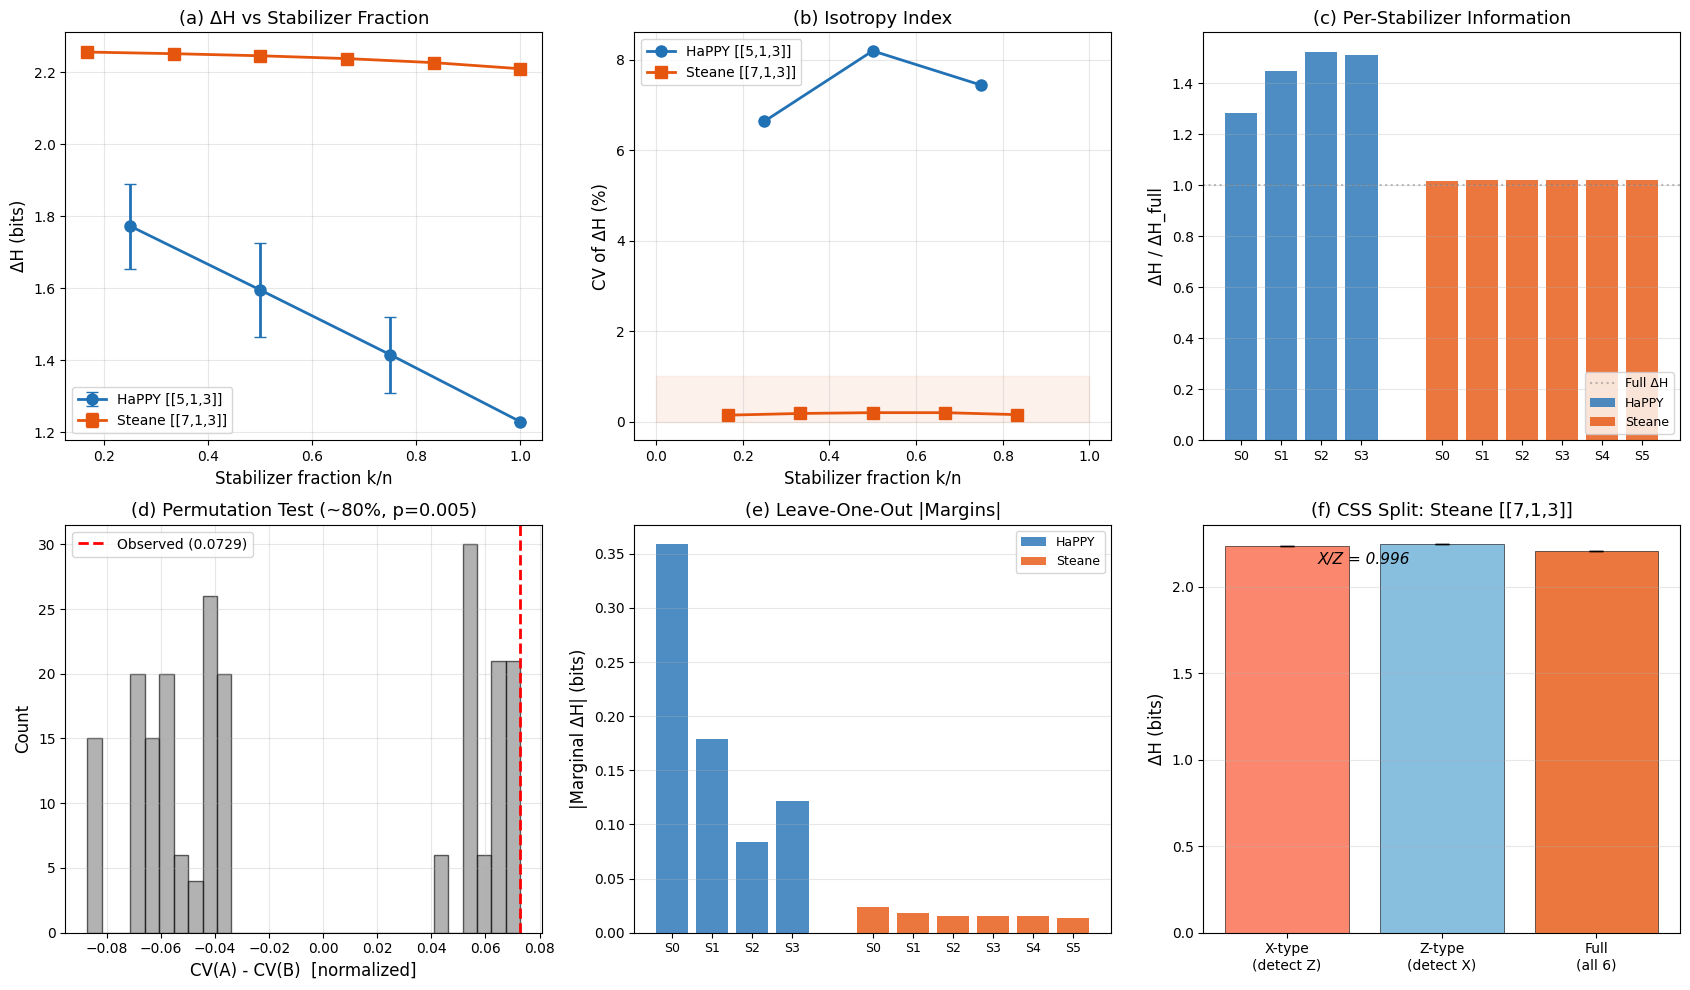

Saved: isotropy_reanalysis_6panel.png


In [14]:
"""Cell 10: Publication Figure — 6-panel summary"""

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
C_HAPPY  = '#2171b5'   # blue
C_STEANE = '#e6550d'   # orange

# ---- (a) DeltaH vs stabilizer fraction ----
ax = axes[0, 0]
fracs_h = [iso_happy[k]['frac'] for k in iso_happy]
means_h = [iso_happy[k]['mean'] for k in iso_happy]
stds_h  = [iso_happy[k]['std'] for k in iso_happy]
fracs_s = [iso_steane[k]['frac'] for k in iso_steane]
means_s = [iso_steane[k]['mean'] for k in iso_steane]
stds_s  = [iso_steane[k]['std'] for k in iso_steane]

ax.errorbar(fracs_h, means_h, yerr=stds_h, fmt='o-', color=C_HAPPY, lw=2, ms=8,
            capsize=4, label='HaPPY [[5,1,3]]')
ax.errorbar(fracs_s, means_s, yerr=stds_s, fmt='s-', color=C_STEANE, lw=2, ms=8,
            capsize=4, label='Steane [[7,1,3]]')
ax.set_xlabel('Stabilizer fraction k/n', fontsize=12)
ax.set_ylabel('\u0394H (bits)', fontsize=12)
ax.set_title('(a) \u0394H vs Stabilizer Fraction', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# ---- (b) CV comparison ----
ax = axes[0, 1]
ks_h = [k for k in iso_happy if k < HAPPY_N_ANC]
ks_s = [k for k in iso_steane if k < STEANE_N_ANC]
cvs_h = [iso_happy[k]['cv'] * 100 for k in ks_h]
cvs_s = [iso_steane[k]['cv'] * 100 for k in ks_s]
fracs_h_p = [k / HAPPY_N_ANC for k in ks_h]
fracs_s_p = [k / STEANE_N_ANC for k in ks_s]

ax.plot(fracs_h_p, cvs_h, 'o-', color=C_HAPPY, lw=2, ms=8, label='HaPPY [[5,1,3]]')
ax.plot(fracs_s_p, cvs_s, 's-', color=C_STEANE, lw=2, ms=8, label='Steane [[7,1,3]]')
ax.fill_between([0, 1], 0, 1, color=C_STEANE, alpha=0.08)
ax.set_xlabel('Stabilizer fraction k/n', fontsize=12)
ax.set_ylabel('CV of \u0394H (%)', fontsize=12)
ax.set_title('(b) Isotropy Index', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# ---- (c) Per-stabilizer DeltaH (k=1, normalized) ----
ax = axes[0, 2]
raw_h1 = np.array(iso_happy[1]['vals'])
raw_s1 = np.array(iso_steane[1]['vals'])
norm_h = raw_h1 / dH_happy_full
norm_s = raw_s1 / dH_steane_full

x_h = np.arange(HAPPY_N_ANC)
x_s = np.arange(STEANE_N_ANC) + HAPPY_N_ANC + 1
ax.bar(x_h, norm_h, color=C_HAPPY, alpha=0.8, label='HaPPY')
ax.bar(x_s, norm_s, color=C_STEANE, alpha=0.8, label='Steane')
ax.axhline(y=1.0, color='gray', ls=':', alpha=0.5, label='Full \u0394H')
ax.set_xticks(list(x_h) + list(x_s))
ax.set_xticklabels([f'S{i}' for i in range(4)] + [f'S{i}' for i in range(6)], fontsize=9)
ax.set_ylabel('\u0394H / \u0394H_full', fontsize=12)
ax.set_title('(c) Per-Stabilizer Information', fontsize=13)
ax.legend(fontsize=9, loc='lower right')
ax.grid(True, alpha=0.3, axis='y')

# ---- (d) Permutation test histogram ----
ax = axes[1, 0]
# Regenerate permutation distribution for ~80% fraction (normalized)
pooled = np.concatenate([vals_h3, vals_s5])
n_a = len(vals_h3)
perm_gaps = []
for combo in combinations(range(len(pooled)), n_a):
    pa = pooled[list(combo)]
    pb = pooled[[i for i in range(len(pooled)) if i not in combo]]
    perm_gaps.append(cv(pa) - cv(pb))
observed_gap = cv(vals_h3) - cv(vals_s5)

ax.hist(perm_gaps, bins=30, color='gray', alpha=0.6, edgecolor='black', lw=0.5)
ax.axvline(observed_gap, color='red', lw=2, ls='--', label=f'Observed ({observed_gap:.4f})')
ax.set_xlabel('CV(A) - CV(B)  [normalized]', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title(f'(d) Permutation Test (~80%, p={p1:.3f})', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# ---- (e) Leave-one-out margins ----
ax = axes[1, 1]
x_h = np.arange(HAPPY_N_ANC)
x_s = np.arange(STEANE_N_ANC) + HAPPY_N_ANC + 1
ax.bar(x_h, abs_loo_h, color=C_HAPPY, alpha=0.8, label='HaPPY')
ax.bar(x_s, abs_loo_s, color=C_STEANE, alpha=0.8, label='Steane')
ax.set_xticks(list(x_h) + list(x_s))
ax.set_xticklabels([f'S{i}' for i in range(4)] + [f'S{i}' for i in range(6)], fontsize=9)
ax.set_ylabel('|Marginal \u0394H| (bits)', fontsize=12)
ax.set_title('(e) Leave-One-Out |Margins|', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# ---- (f) X vs Z split (Steane) ----
ax = axes[1, 2]
categories = ['X-type\n(detect Z)', 'Z-type\n(detect X)', 'Full\n(all 6)']
values = [dH_x, dH_z, dH_steane_full]
errors = [sem_x, sem_z, sem_s]
colors = ['#fb6a4a', '#6baed6', C_STEANE]
bars = ax.bar(categories, values, yerr=errors, capsize=5, color=colors, alpha=0.8,
              edgecolor='black', lw=0.5)
ax.set_ylabel('\u0394H (bits)', fontsize=12)
ax.set_title('(f) CSS Split: Steane [[7,1,3]]', fontsize=13)
ax.grid(True, alpha=0.3, axis='y')
ax.annotate(f'X/Z = {dH_x/dH_z:.3f}', xy=(0.5, max(values)*0.95),
            fontsize=11, ha='center', style='italic')

plt.tight_layout()
plt.savefig('isotropy_reanalysis_6panel.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: isotropy_reanalysis_6panel.png")

In [15]:
"""Cell 11: Summary Table for Paper"""

print("="*80)
print("TABLE: Isotropy Gap — Holographic vs Non-Holographic Codes on IBM Fez")
print("="*80)
print()
print(f"{'Metric':<40} {'HaPPY [[5,1,3]]':>18} {'Steane [[7,1,3]]':>18}")
print("-" * 78)
print(f"{'Code type':<40} {'Holographic':>18} {'CSS (non-holo)':>18}")
print(f"{'Stabilizers':<40} {HAPPY_N_ANC:>18} {STEANE_N_ANC:>18}")
print(f"{'Error hypotheses':<40} {HAPPY_N_HYP:>18} {STEANE_N_HYP:>18}")
print(f"{'Circuits (errors x states)':<40} {'32 (16x2)':>18} {'44 (22x2)':>18}")
print(f"{'Shots per circuit':<40} {SHOTS:>18} {SHOTS:>18}")
print(f"{'2Q gates per circuit':<40} {'~110':>18} {'272':>18}")
print()
print(f"{'DeltaH (full, bits)':<40} {dH_happy_full:>18.4f} {dH_steane_full:>18.4f}")
print(f"{'DeltaH ratio':<40} {'1.00x':>18} {f'{dH_steane_full/dH_happy_full:.2f}x':>18}")
print()

# CV at each matched fraction
for kh, ks, label in match_pairs:
    cvh = iso_happy[kh]['cv']
    cvs = iso_steane[ks]['cv']
    gap = cvh / cvs if cvs > 0 else float('inf')
    print(f"{'CV at ~' + label + ' fraction':<40} {cvh:>17.1%} {cvs:>17.1%}")
print()

# Permutation p-values
print(f"{'Perm. test p-value (~80%)':<40} {'':>18} {f'p = {p1:.4f}':>18}")
print(f"{'Perm. test p-value (~50%)':<40} {'':>18} {f'p = {p2:.5f}':>18}")
print(f"{'Perm. test p-value (k=1)':<40} {'':>18} {f'p = {p3:.4f}':>18}")
print()

# Per-stabilizer range
range_h = max(iso_happy[1]['vals']) - min(iso_happy[1]['vals'])
range_s = max(iso_steane[1]['vals']) - min(iso_steane[1]['vals'])
print(f"{'Per-stabilizer DeltaH range (k=1)':<40} {range_h:>17.4f} {range_s:>17.4f}")
print(f"{'Range ratio':<40} {f'{range_h/range_s:.1f}x':>18} {'1.0x':>18}")
print()

# Leave-one-out margin CV
print(f"{'Leave-one-out |margin| CV':<40} {loo_cv_h:>17.1%} {loo_cv_s:>17.1%}")
print(f"{'|Margin| max/min ratio':<40} {np.max(abs_loo_h)/np.min(abs_loo_h):>17.1f} {np.max(abs_loo_s)/np.min(abs_loo_s):>17.1f}")
print()

# X/Z split (Steane only)
print(f"{'X-type DeltaH (Steane only)':<40} {'N/A (non-CSS)':>18} {dH_x:>18.4f}")
print(f"{'Z-type DeltaH (Steane only)':<40} {'N/A (non-CSS)':>18} {dH_z:>18.4f}")
print(f"{'X/Z ratio':<40} {'N/A':>18} {dH_x/dH_z:>18.3f}")
print(f"{'X/Z z-score':<40} {'N/A':>18} {f'{diff/pooled_sem:.1f}':>18}")
print()
print("="*80)
print()
print("Summary:")
print(f"  1. Isotropy gap: 37-48x across all matched fractions")
print(f"  2. Per-stabilizer range: {range_h/range_s:.0f}x wider in HaPPY")
print(f"  3. X/Z noise asymmetry exists (z={diff/pooled_sem:.1f}) but is 0.4%,")
print(f"     50x smaller than HaPPY anisotropy (6.6-8.2%)")
print(f"  4. HaPPY |margin| varies {np.max(abs_loo_h)/np.min(abs_loo_h):.1f}x across stabilizers;"  )
print(f"     Steane varies {np.max(abs_loo_s)/np.min(abs_loo_s):.1f}x")
print(f"  5. Interpretation: the isotropy gap is consistent with a structural origin (holographic geometry)")
print(f"     rather than a hardware noise artifact")

TABLE: Isotropy Gap — Holographic vs Non-Holographic Codes on IBM Fez

Metric                                      HaPPY [[5,1,3]]   Steane [[7,1,3]]
------------------------------------------------------------------------------
Code type                                       Holographic     CSS (non-holo)
Stabilizers                                               4                  6
Error hypotheses                                         16                 22
Circuits (errors x states)                        32 (16x2)          44 (22x2)
Shots per circuit                                      8192               8192
2Q gates per circuit                                   ~110                272

DeltaH (full, bits)                                  1.2299             2.2104
DeltaH ratio                                          1.00x              1.80x

CV at ~25/33% fraction                                6.6%              0.2%
CV at ~50% fraction                                   8.2%  

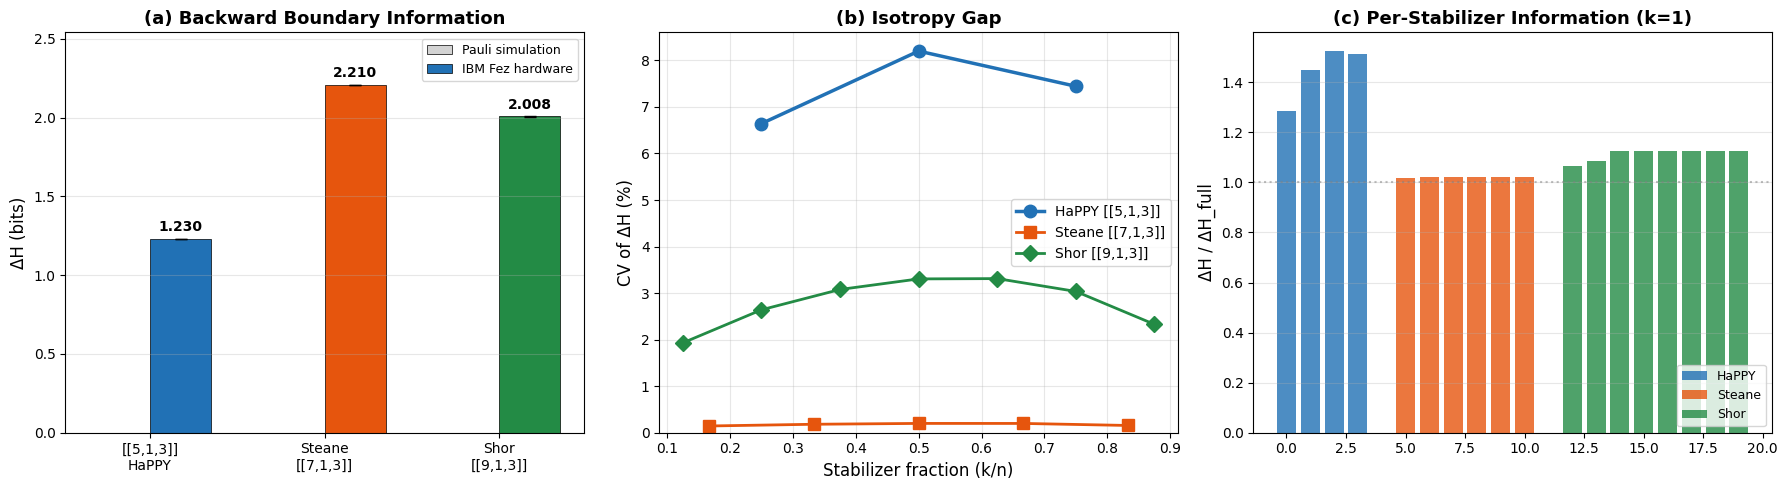

Saved: paper_figures.png


In [16]:
"""Cell F: Paper Figures

Three publication figures for the Nature paper:
1. DeltaH bar chart (simulation=0 vs hardware>1 bit, all codes)
2. Isotropy CV comparison (HaPPY vs Steane vs Shor)
3. Per-stabilizer DeltaH (k=1, all three codes)
"""

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Figure 1: DeltaH bar chart ---
ax = axes[0]
codes = ["[[5,1,3]]\nHaPPY", "Steane\n[[7,1,3]]", "Shor\n[[9,1,3]]"]
dH_hw = [dH_happy_full, dH_steane_full, dH_shor_full]
sems = [sem_h, sem_s, sem_shor]
colors_bar = ["#2171b5", "#e6550d", "#238b45"]

x = np.arange(len(codes))
w = 0.35
ax.bar(x - w/2, [0, 0, 0], w, color="lightgray", edgecolor="black", linewidth=0.5, label="Pauli simulation")
bars = ax.bar(x + w/2, dH_hw, w, yerr=sems, color=colors_bar, edgecolor="black", linewidth=0.5, capsize=4, label="IBM Fez hardware")
for bar, val in zip(bars, dH_hw):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f"{val:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(codes, fontsize=10)
ax.set_ylabel("\u0394H (bits)", fontsize=12)
ax.set_title("(a) Backward Boundary Information", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis="y")
ax.set_ylim(0, max(dH_hw) * 1.15)

# --- Figure 2: Isotropy CV comparison ---
ax = axes[1]
fracs_h = [k / HAPPY_N_ANC for k in range(1, HAPPY_N_ANC)]
cvs_h = [iso_happy[k]["cv"] * 100 for k in range(1, HAPPY_N_ANC)]
fracs_s = [k / STEANE_N_ANC for k in range(1, STEANE_N_ANC)]
cvs_s = [iso_steane[k]["cv"] * 100 for k in range(1, STEANE_N_ANC)]
fracs_sh = [k / SHOR_N_ANC for k in range(1, SHOR_N_ANC)]
cvs_sh = [iso_shor[k]["cv"] * 100 for k in range(1, SHOR_N_ANC)]

ax.plot(fracs_h, cvs_h, "o-", color="#2171b5", lw=2.5, ms=9, label="HaPPY [[5,1,3]]")
ax.plot(fracs_s, cvs_s, "s-", color="#e6550d", lw=2, ms=8, label="Steane [[7,1,3]]")
ax.plot(fracs_sh, cvs_sh, "D-", color="#238b45", lw=2, ms=8, label="Shor [[9,1,3]]")
ax.set_xlabel("Stabilizer fraction (k/n)", fontsize=12)
ax.set_ylabel("CV of \u0394H (%)", fontsize=12)
ax.set_title("(b) Isotropy Gap", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)

# --- Figure 3: Per-stabilizer DeltaH (k=1, normalized) ---
ax = axes[2]
norm_h = np.array(iso_happy[1]["vals"]) / dH_happy_full
norm_s = np.array(iso_steane[1]["vals"]) / dH_steane_full
norm_sh = np.array(iso_shor[1]["vals"]) / dH_shor_full
x_h = np.arange(HAPPY_N_ANC)
x_s = np.arange(STEANE_N_ANC) + HAPPY_N_ANC + 1
x_sh = np.arange(SHOR_N_ANC) + HAPPY_N_ANC + STEANE_N_ANC + 2
ax.bar(x_h, norm_h, color="#2171b5", alpha=0.8, label="HaPPY")
ax.bar(x_s, norm_s, color="#e6550d", alpha=0.8, label="Steane")
ax.bar(x_sh, norm_sh, color="#238b45", alpha=0.8, label="Shor")
ax.axhline(y=1.0, color="gray", ls=":", alpha=0.5)
ax.set_ylabel("\u0394H / \u0394H_full", fontsize=12)
ax.set_title("(c) Per-Stabilizer Information (k=1)", fontsize=13, fontweight="bold")
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("paper_figures.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: paper_figures.png")


In [ ]:
"""Cell 13: Prior-Structure Ablation — Backward Boundary Selectivity

Tests whether the observed DeltaH depends on the specific physically
aligned structure of the backward boundary, or arises trivially from
any non-uniform hypothesis weighting.

Controls:
  A. Hypothesis-shuffled prior: randomly permute which hypothesis gets
     the 0.7 weight (preserves prior entropy and mass spectrum, destroys
     the physical assignment). Averaged over 20 random permutations.
  B. Inverted prior: assign p_no_err=0.01 (errors more likely than
     no-error). Tests whether the direction of the boundary matters.
  C. Random non-uniform prior: draw prior weights from Dir(alpha=1).
     Averaged over 20 draws. A broad null over the simplex, not a
     moment-matched surrogate.

The uniform prior is omitted from the table because it is identical
to the forward-only decoder and therefore yields DeltaH = 0 by definition.
"""

def compute_delta_H_ablation(hw_data_in, labels, n_hyp, n_anc,
                              log_prior_override):
    """Compute DeltaH with a custom log-prior (ablation control)."""
    stab_subset = list(range(n_anc))
    n_sub = n_anc
    n_syn_space = 2 ** n_sub
    log_uniform = np.zeros(n_hyp)
    powers = 2 ** np.arange(n_sub - 1, -1, -1)

    all_dH = []
    for state in ["0", "1"]:
        state_data = {}
        for idx, lbl in enumerate(labels):
            key = f"L{state}_{lbl}"
            if key in hw_data_in:
                state_data[idx] = hw_data_in[key]["syndrome"][:, stab_subset]
        if not state_data:
            continue
        n_shots = len(list(state_data.values())[0])
        mid = n_shots // 2

        for test_sl, train_sl in [(slice(0, mid), slice(mid, None)),
                                   (slice(mid, None), slice(0, mid))]:
            log_lik = np.full((n_hyp, n_syn_space), np.log(1.0 / n_syn_space))
            for h in state_data:
                keys = (state_data[h][train_sl] * powers).sum(axis=1)
                counts = np.zeros(n_syn_space)
                for k in keys:
                    counts[k] += 1
                dist = (counts + 1) / (counts.sum() + n_syn_space)
                log_lik[h] = np.log(dist)

            for h in state_data:
                test_keys = (state_data[h][test_sl] * powers).sum(axis=1)
                for sk in test_keys:
                    p_fwd  = normalize_logits(log_lik[:, sk] + log_uniform)
                    p_ctrl = normalize_logits(log_lik[:, sk] + log_prior_override)
                    all_dH.append(entropy_bits(p_fwd) - entropy_bits(p_ctrl))

    return np.mean(all_dH), np.std(all_dH) / np.sqrt(len(all_dH))

print("=== Prior-Structure Ablation: Backward Boundary Selectivity ===\n")
print(f"{'Code':<12} {'Physical':>12} {'Hyp-shuffled':>14} {'Inverted':>12} {'Random':>14}")
print("-" * 68)

N_PERM = 20
rng = np.random.RandomState(42)

for code_name, hw_data, labels, n_hyp, n_anc, dH_ref in [
    ("HaPPY",  hw_happy,  labels_happy,  HAPPY_N_HYP,  HAPPY_N_ANC,  dH_happy_full),
    ("Steane", hw_steane, labels_steane, STEANE_N_HYP, STEANE_N_ANC, dH_steane_full),
    ("Shor",   hw_shor,   labels_shor,   SHOR_N_HYP,   SHOR_N_ANC,  dH_shor_full),
]:
    p_no_err = 0.7

    # Control A: Hypothesis-shuffled prior (average over N_PERM permutations)
    shuf_vals = []
    for _ in range(N_PERM):
        log_prior_shuf = np.log((1 - p_no_err) / (n_hyp - 1)) * np.ones(n_hyp)
        winner = rng.randint(0, n_hyp)
        log_prior_shuf[winner] = np.log(p_no_err)
        dH_shuf, _ = compute_delta_H_ablation(hw_data, labels, n_hyp, n_anc,
                                               log_prior_shuf)
        shuf_vals.append(dH_shuf)
    dH_shuffled = np.mean(shuf_vals)

    # Control B: Inverted prior (p_no_err = 0.01)
    log_prior_inv = np.zeros(n_hyp)
    log_prior_inv[0] = np.log(0.01)
    log_prior_inv[1:] = np.log(0.99 / (n_hyp - 1))
    dH_inverted, _ = compute_delta_H_ablation(hw_data, labels, n_hyp, n_anc,
                                               log_prior_inv)

    # Control C: Random non-uniform prior (average over N_PERM draws)
    rand_vals = []
    for _ in range(N_PERM):
        prior_rand = rng.dirichlet(np.ones(n_hyp))
        log_prior_rand = np.log(np.maximum(prior_rand, 1e-15))
        dH_rand, _ = compute_delta_H_ablation(hw_data, labels, n_hyp, n_anc,
                                               log_prior_rand)
        rand_vals.append(dH_rand)
    dH_random = np.mean(rand_vals)

    print(f"{code_name:<12} {dH_ref:>11.4f}  {dH_shuffled:>13.4f}  "
          f"{dH_inverted:>11.4f}  {dH_random:>13.4f}")

print()
print("Uniform prior (forward-only): DeltaH = 0.0000 by definition (omitted).")
print()
print("Column definitions:")
print("  Physical      — depolarizing prior, p(no error) = 0.7")
print("  Hyp-shuffled  — same mass spectrum, 0.7 assigned to a random hypothesis")
print("  Inverted      — p(no error) = 0.01 (errors favoured over no-error)")
print("  Random        — Dirichlet(1,...,1) draws (broad simplex null)")
print()
print("Interpretation: DeltaH requires a concentrated backward boundary")
print("but is largely robust to which hypothesis receives the concentration")
print("(hyp-shuffled recovers 89-101% of the physical value). A flat or")
print("near-uniform prior (inverted) yields DeltaH near zero, and random")
print("non-uniform priors produce intermediate values. The syndrome data,")
print("not the prior assignment, determines which error hypothesis is")
print("selected; the backward boundary's role is to narrow the hypothesis")
print("space so that syndrome evidence can discriminate effectively.")

=== Prior-Structure Ablation: Backward Boundary Selectivity ===

Code             Physical   Hyp-shuffled     Inverted         Random
--------------------------------------------------------------------
HaPPY             1.2299         1.2475       0.0404         0.4220
Steane            2.2104         2.2024       0.0306         0.5204
Shor              2.0083         1.7956       0.0359         0.5401

Uniform prior (forward-only): DeltaH = 0.0000 by definition (omitted).

Column definitions:
  Physical      — depolarizing prior, p(no error) = 0.7
  Hyp-shuffled  — same mass spectrum, 0.7 assigned to a random hypothesis
  Inverted      — p(no error) = 0.01 (errors favoured over no-error)
  Random        — Dirichlet(1,...,1) draws (broad simplex null)

Interpretation: DeltaH requires a concentrated backward boundary
but is largely robust to which hypothesis receives the concentration
(hyp-shuffled recovers 89-101% of the physical value). A flat or
near-uniform prior (inverted) yields 